# Wahl-O-Mat Feature Analysis

In [ ]:
%load_ext autoreload
%autoreload 2
import helper
import plotting
import constants
import pandas as pd
from datetime import datetime
import numpy as np
import ast
import matplotlib.pyplot as plt
import pm4py

In [ ]:
berlin_df = pm4py.read_xes("./data-xes/Berlin-2021-2023-with-topics-and-agreement-scores.xes")
berlin_df_allTime = pm4py.read_xes("./data-xes/Berlin-all-time-with-topics-and-agreement-scores.xes")
bawue_df = pm4py.read_xes("./data-xes/Bawue-2021-with-topics-and-agreement-scores.xes")

parsing log, completed traces ::   0%|          | 0/157 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/1813 [00:00<?, ?it/s]

parsing log, completed traces ::   0%|          | 0/132 [00:00<?, ?it/s]

In [ ]:
passed_bills_activities_berlin = ['Gesetz- und Verordnungsblatt', 'Bekanntmachung (Gesetz- und Verordnungsblatt)']
passed_bills_activities_bawue = ["Gesetz", "Gesetzblatt für Baden-Württemberg"]
passed_bills_activities_brandenburg = ["Gesetz", "Gesetz- und Verordnungsblatt"]

possible_passed_bills_activities = passed_bills_activities_berlin + passed_bills_activities_bawue + passed_bills_activities_brandenburg

def generate_passed_bill_column(df):
    df["is_passed_bill"] = df.groupby("case:concept:name")["concept:name"].transform(lambda x: x.isin(possible_passed_bills_activities).any())
    return df

def generate_end_date_column(df):
    df["endDate"] = (
        df.groupby("case:concept:name")["time:timestamp"]
        .transform("max")
    )
    return df

berlin_df = generate_passed_bill_column(berlin_df)
berlin_df = generate_end_date_column(berlin_df)
bawue_df = generate_passed_bill_column(bawue_df)
bawue_df = generate_end_date_column(bawue_df)
berlin_df_allTime = generate_passed_bill_column(berlin_df_allTime)
berlin_df_allTime = generate_end_date_column(berlin_df_allTime)

In [ ]:
def meanCycleTime(dataframe):
    cycle_times = cycleTimes(dataframe)
    return np.mean(cycle_times)

def cycleTimes(dataframe):
    # Get all case durations in seconds
    durations = pm4py.get_all_case_durations(dataframe)
    # Convert to days    
    durations_in_days = np.array(durations)/60/60/24
    return durations_in_days



berlin_cycle_time = meanCycleTime(berlin_df)
bawue_cycle_time = meanCycleTime(bawue_df)
#print(f"Average cycle time for Berlin: {berlin_cycle_time:.2f} days")
#print(f"Average cycle time for Baden-Württemberg: {bawue_cycle_time:.2f} days")

#berlin_cycle_times = cycleTimes(berlin_df)
#bawue_cycle_times = cycleTimes(bawue_df)

# Calculate cycle time per case and broadcast to all rows in the case
berlin_df['cycle_time'] = berlin_df.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
berlin_df['cycle_time_seconds'] = berlin_df['cycle_time'].dt.total_seconds()
bawue_df['cycle_time'] = bawue_df.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
bawue_df['cycle_time_seconds'] = bawue_df['cycle_time'].dt.total_seconds()
berlin_df_allTime['cycle_time'] = berlin_df_allTime.groupby('case:concept:name')["time:timestamp"].transform(lambda x: x.max() - x.min())
berlin_df_allTime['cycle_time_seconds'] = berlin_df_allTime['cycle_time'].dt.total_seconds()


berlin_df_grouped = berlin_df.groupby("case:concept:name").first().reset_index()
bawue_df_grouped = bawue_df.groupby("case:concept:name").first().reset_index()
berlin_df_allTime_grouped = berlin_df_allTime.groupby("case:concept:name").first().reset_index()


'''
# Testing if the cycle times are calculated correctly:
# Take one row per case to avoid counting multiple events
cycle_times_per_case = berlin_df[['case:concept:name', 'cycle_time']].drop_duplicates()
mean_cycle_time = cycle_times_per_case['cycle_time'].mean()
print("Mean cycle time per case:", mean_cycle_time)
# Take one row per case to avoid counting multiple events
cycle_times_per_case = bawue_df[['case:concept:name', 'cycle_time']].drop_duplicates()
mean_cycle_time = cycle_times_per_case['cycle_time'].mean()
print("Mean cycle time per case:", mean_cycle_time)
'''


'\n# Testing if the cycle times are calculated correctly:\n# Take one row per case to avoid counting multiple events\ncycle_times_per_case = berlin_df[[\'case:concept:name\', \'cycle_time\']].drop_duplicates()\nmean_cycle_time = cycle_times_per_case[\'cycle_time\'].mean()\nprint("Mean cycle time per case:", mean_cycle_time)\n# Take one row per case to avoid counting multiple events\ncycle_times_per_case = bawue_df[[\'case:concept:name\', \'cycle_time\']].drop_duplicates()\nmean_cycle_time = cycle_times_per_case[\'cycle_time\'].mean()\nprint("Mean cycle time per case:", mean_cycle_time)\n'

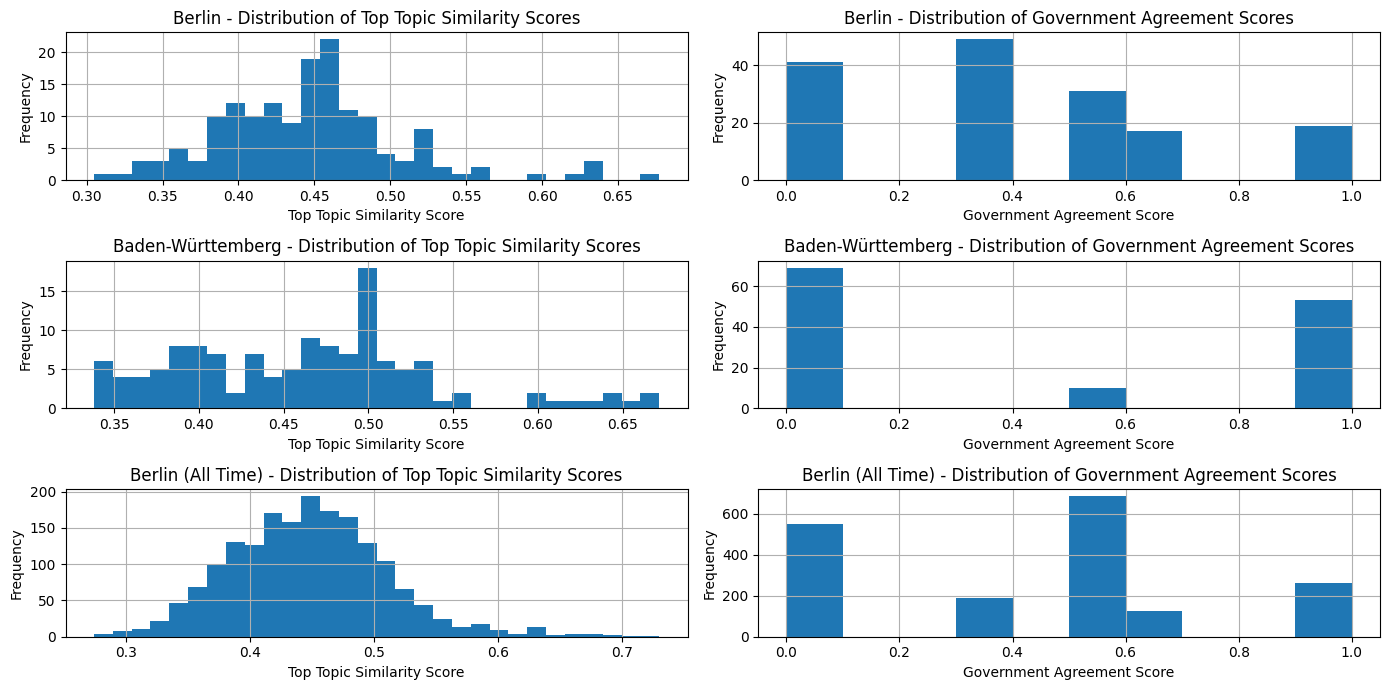

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 7))

berlin_df_grouped["top_topic_similarity_score"].hist(bins=30, ax=axes[0, 0])
axes[0, 0].set_xlabel("Top Topic Similarity Score")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_title("Berlin - Distribution of Top Topic Similarity Scores")

berlin_df_grouped["government_agreement_score"].hist(bins=10, ax=axes[0, 1])
axes[0, 1].set_xlabel("Government Agreement Score")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Berlin - Distribution of Government Agreement Scores")

bawue_df_grouped["top_topic_similarity_score"].hist(bins=30, ax=axes[1, 0])
axes[1, 0].set_xlabel("Top Topic Similarity Score")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Baden-Württemberg - Distribution of Top Topic Similarity Scores")

bawue_df_grouped["government_agreement_score"].hist(bins=10, ax=axes[1, 1])
axes[1, 1].set_xlabel("Government Agreement Score")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Baden-Württemberg - Distribution of Government Agreement Scores")

berlin_df_allTime_grouped["top_topic_similarity_score"].hist(bins=30, ax=axes[2, 0])
axes[2, 0].set_xlabel("Top Topic Similarity Score")
axes[2, 0].set_ylabel("Frequency")
axes[2, 0].set_title("Berlin (All Time) - Distribution of Top Topic Similarity Scores")

berlin_df_allTime_grouped["government_agreement_score"].hist(bins=10, ax=axes[2, 1])
axes[2, 1].set_xlabel("Government Agreement Score")
axes[2, 1].set_ylabel("Frequency")
axes[2, 1].set_title("Berlin (All Time) - Distribution of Government Agreement Scores")

plt.tight_layout()
plt.show()

# Correlations Cycle Times and Agreement Scores

In [ ]:
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

def test_correlations(dataframe, target_col, topic_similarity_threshold_lower, topic_similarity_threshold_upper, plot=False):
    
    dataframe = dataframe[
        dataframe["top_topic_similarity_score"].between(
            topic_similarity_threshold_lower,
            topic_similarity_threshold_upper,
            inclusive="both"
        )
    ].copy()

    if dataframe.empty:
        print("No rows left after filtering top_topic_similarity_score.")
        return

    # Convert cycle_time to numeric seconds
    dataframe['cycle_time_seconds'] = dataframe['cycle_time'].dt.total_seconds()
    
    x = dataframe['cycle_time_seconds']
    y = dataframe[target_col]
    
    # Pearson test
    pearson_corr, pearson_p = pearsonr(x, y)
    print(f"Pearson correlation: {pearson_corr:.3f}, p-value: {pearson_p:.3f}")
    
    # Spearman test
    spearman_corr, spearman_p = spearmanr(x, y)
    print(f"Spearman correlation: {spearman_corr:.3f}, p-value: {spearman_p:.3f}")
    
    # Kendall tau test
    kendall_corr, kendall_p = kendalltau(x, y)
    print(f"Kendall tau correlation: {kendall_corr:.3f}, p-value: {kendall_p:.3f}")
    
    # Optional scatter plot with regression line
    if plot:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=x, y=y, s=50, alpha=0.7)
        sns.regplot(x=x, y=y, scatter=False, color='orange', line_kws={"linewidth":1})
        plt.xlabel("Cycle time (seconds)")
        plt.ylabel(target_col)
        plt.title(f"Cycle time vs {target_col}\nPearson r={pearson_corr:.2f}, p={pearson_p:.3f}")
        plt.tight_layout()
        plt.show()


In [ ]:
withPlots = False

def test_correlations_groups(dataframe, lower_threshold, upper_threshold, withPlots):
    print("\ngovernment agreement score:")
    test_correlations(dataframe, 'government_agreement_score', lower_threshold, upper_threshold, withPlots)
    print("\nopposition agreement score:")
    test_correlations(dataframe, 'opposition_agreement_score', lower_threshold, upper_threshold, withPlots)
    print("\nall agreement score:")
    test_correlations(dataframe, 'all_agreement_score', lower_threshold, upper_threshold, withPlots)

print("Berlin - Correlation between cycle time and ...")
test_correlations_groups(berlin_df_grouped, 0.5, 1, withPlots)

print("\n\n-----------------------------------\n\n")

print("Baden-Württemberg - Correlation between cycle time and ...")
test_correlations_groups(bawue_df_grouped, 0.5, 1, withPlots)

print("\n\n-----------------------------------\n\n")


print("Berlin ALL TIME - Correlation between cycle time and ...")
test_correlations_groups(berlin_df_allTime_grouped, 0.5, 1, withPlots)

print("\n\n-----------------------------------\n\n")

Berlin - Correlation between cycle time and ...

government agreement score:
Pearson correlation: -0.336, p-value: 0.126
Spearman correlation: -0.337, p-value: 0.125
Kendall tau correlation: -0.266, p-value: 0.108

opposition agreement score:
Pearson correlation: -0.031, p-value: 0.890
Spearman correlation: -0.219, p-value: 0.328
Kendall tau correlation: -0.183, p-value: 0.316

all agreement score:
Pearson correlation: -0.382, p-value: 0.079
Spearman correlation: -0.329, p-value: 0.135
Kendall tau correlation: -0.273, p-value: 0.110


-----------------------------------


Baden-Württemberg - Correlation between cycle time and ...

government agreement score:
Pearson correlation: -0.099, p-value: 0.547
Spearman correlation: -0.117, p-value: 0.477
Kendall tau correlation: -0.097, p-value: 0.475

opposition agreement score:
Pearson correlation: 0.168, p-value: 0.307
Spearman correlation: -0.155, p-value: 0.347
Kendall tau correlation: -0.116, p-value: 0.391

all agreement score:
Pearson c

## Further ideas

1. compare cycle times of different "groups" (e.g., processes for full agreement and maximal disagreement topics)
3. ToDo: We could assume that the WahlOMat agreement scores on topics also apply to the other election periods and see if there is something (ToDo: finish analysis - data should be there, doublecheck though)
    * plot somehow - e.g. for each election period over the 5 years - are topic tackled first where the government has full agreement? Later then other laws?
4. ToDo: Look for best fitting law proposal for each of the wahl-o-mat theses and check for differences just among those
5. ToDo: For all WahlOMat Analysis: Filter by threshold of topic similarity scores - e.g., only use well matched cases for analysis
6. Look closer at groups like fastest and slowest 10% - e.g. is it that the fastest are usually about topics of high agreement?
7. Cycle Time Distributions across the election periods - use different coloring for different explanation possibilities (e.g. colors for who is in the government coalition or how many parties are in the government coalition)

#### Could be considered later: 
* Wahlergebnisse irgendwie miteinbeziehen?
* Consider who is the Urheber of a Gesetzentwurf
* Consider Topics of Gesetzentwürfe (via embedding or Deskriptoren/Systematiken?)
* Linguistic stuff: Simones alignment score auf Basis von Begründungen? Check out Simones papers of these topics

#### Notes:
* Hypothese: Konsensbildung außerhalb unseres Prozesses - ist bereits in der Exekutive außerhalb des Parlamentes passiert - vermutlich gibt es Literatur dazu
* Also: WahlOMat only gives direction - parties can still fight about details - e.g. Mindestlohn - everybody can want a Mindestlohn, but exact amounts can be very different 




## 1. Check Cycle times no distance and maximal distance groups
- full agreement group: traces that have similar topics to a wahlomat thesis on which the government agreement score signals complete agreement
- maxium disagreement group: if 2 government parties: 1 means maximum distance and no agreement at all, otherwise for 3 government parties the highest possible disagreement score should be 2/3 (I think? See what it is exactly)
- TODO: do this for all parliaments and all election periods programatically - and find better way to summarize and check results... maybe Mann-Whitney U test across the groups to check for statistically significant differences of the cycle times in those groups?

#### Berlin

In [ ]:
# separate data from the two election periods (before and after 16.03.2023) for Berlin
cutoff = pd.to_datetime("16.03.2023", dayfirst=True, utc=True)

berlin_2021_grouped = berlin_df_grouped[
    (berlin_df_grouped['DokDat'] < cutoff) & (berlin_df_grouped["endDate"] < cutoff)
]

berlin_2023_grouped = berlin_df_grouped[
    berlin_df_grouped['DokDat'] >= cutoff
]

print("no. of cases in 2021:", len(berlin_2021_grouped))
print("no. ofcases in 2023:", len(berlin_2023_grouped))
print("no. of cases in all time:", len(berlin_df_allTime_grouped))

berlin_2021_grouped_passed_bills = berlin_2021_grouped[berlin_2021_grouped['is_passed_bill']]
berlin_2023_grouped_passed_bills = berlin_2023_grouped[berlin_2023_grouped['is_passed_bill']]
berlin_allTime_grouped_passed_bills = berlin_df_allTime_grouped[berlin_df_allTime_grouped['is_passed_bill']]
print("no. of traces leading to passed bills in 2021:", len(berlin_2021_grouped_passed_bills))
print("no. of traces leading to passed bills in 2023:", len(berlin_2023_grouped_passed_bills))
print("no. of traces leading to passed bills in all time:", len(berlin_allTime_grouped_passed_bills))

no. of cases in 2021: 62
no. ofcases in 2023: 69
no. of cases in all time: 1813
no. of traces leading to passed bills in 2021: 43
no. of traces leading to passed bills in 2023: 52
no. of traces leading to passed bills in all time: 1313


In [ ]:
def test_agreement_score_groups(grouped_df, is2021=False):
    full_agreement_group = grouped_df[grouped_df['government_agreement_score'] == 0.0]
    print("amount of traces with full agreement:", len(full_agreement_group))

    # TODO: make this dynamic according to the grouped_df properties? Is dependent on the amount of parties in the groups (e.g. 3 parties can never have 1 as maximum disagreement...)
    maximum_disagreement_score = 2/3 if is2021 else 1.0  

    no_agreement_group = grouped_df[grouped_df['government_agreement_score'] == maximum_disagreement_score]
    print("amount of traces with no agreement:", len(no_agreement_group))
    #print("topics of no agreement group:", no_agreement_group["top_topic"]) # CHECK THIS - IT IS WEIRD MAYBE BECAUSE THERE ARE SO MANY 11

    
    
    partial_agreement_group = grouped_df[
        (grouped_df['government_agreement_score'] > 0.0) & (grouped_df['government_agreement_score'] < maximum_disagreement_score)
    ]
    print("amount of traces with partial agreement:", len(partial_agreement_group))
    print("-----------------------------------")

    # now get cycle times for these groups
    overall_cycle_times = grouped_df["cycle_time_seconds"] /60/60/24
    full_agreement_cycle_times = full_agreement_group["cycle_time_seconds"] / 60/60/24
    no_agreement_cycle_times = no_agreement_group["cycle_time_seconds"] / 60/60/24
    partial_agreement_cycle_times = partial_agreement_group["cycle_time_seconds"] / 60/60/24

    print(f"Overall - median cycle time: {np.median(overall_cycle_times):.2f} days, mean cycle time: {np.mean(overall_cycle_times):.2f} days")
    print(f"Full agreement - median cycle time: {np.median(full_agreement_cycle_times):.2f} days, mean cycle time: {np.mean(full_agreement_cycle_times):.2f} days")
    print(f"No agreement - median cycle time: {np.median(no_agreement_cycle_times):.2f} days, mean cycle time: {np.mean(no_agreement_cycle_times):.2f} days")
    print(f"Partial agreement - median cycle time: {np.median(partial_agreement_cycle_times):.2f} days, mean cycle time: {np.mean(partial_agreement_cycle_times):.2f} days")



print("BERLIN 2023")
print("All traces:")
test_agreement_score_groups(berlin_2023_grouped)
print("-----------------------------------\n")
print("Only traces with passed bills:")
test_agreement_score_groups(berlin_2023_grouped_passed_bills)

print("\n\n-----------------------------------\n\n")

print("BERLIN 2021")
print("All traces:")
test_agreement_score_groups(berlin_2021_grouped, is2021=True)
print("-----------------------------------")
print("Only traces with passed bills:")
test_agreement_score_groups(berlin_2021_grouped_passed_bills, is2021=True)

print("\n\n-----------------------------------\n\n")

print("BERLIN ALL TIME")
print("All traces:")
test_agreement_score_groups(berlin_df_allTime_grouped, is2021=True)
print("-----------------------------------")
print("Only traces with passed bills:")
test_agreement_score_groups(berlin_allTime_grouped_passed_bills, is2021=True)


BERLIN 2023
All traces:
amount of traces with full agreement: 19
amount of traces with no agreement: 19
amount of traces with partial agreement: 31
-----------------------------------
Overall - median cycle time: 86.00 days, mean cycle time: 99.81 days
Full agreement - median cycle time: 77.00 days, mean cycle time: 99.53 days
No agreement - median cycle time: 99.00 days, mean cycle time: 102.47 days
Partial agreement - median cycle time: 84.00 days, mean cycle time: 98.35 days
-----------------------------------

Only traces with passed bills:
amount of traces with full agreement: 14
amount of traces with no agreement: 13
amount of traces with partial agreement: 25
-----------------------------------
Overall - median cycle time: 77.50 days, mean cycle time: 85.83 days
Full agreement - median cycle time: 57.00 days, mean cycle time: 73.93 days
No agreement - median cycle time: 99.00 days, mean cycle time: 91.85 days
Partial agreement - median cycle time: 78.00 days, mean cycle time: 89

#### BaWue

In [ ]:
bawue_grouped_passed_bills = bawue_df_grouped[bawue_df_grouped['is_passed_bill']]


print("BAWUE")
print("All traces:")
test_agreement_score_groups(bawue_df_grouped)
print("-----------------------------------")
print("Only traces with passed bills:")
test_agreement_score_groups(bawue_grouped_passed_bills)


BAWUE
All traces:
amount of traces with full agreement: 69
amount of traces with no agreement: 53
amount of traces with partial agreement: 10
-----------------------------------
Overall - median cycle time: 62.50 days, mean cycle time: 92.77 days
Full agreement - median cycle time: 65.00 days, mean cycle time: 97.74 days
No agreement - median cycle time: 57.00 days, mean cycle time: 84.77 days
Partial agreement - median cycle time: 64.00 days, mean cycle time: 100.80 days
-----------------------------------
Only traces with passed bills:
amount of traces with full agreement: 47
amount of traces with no agreement: 18
amount of traces with partial agreement: 8
-----------------------------------
Overall - median cycle time: 66.00 days, mean cycle time: 94.88 days
Full agreement - median cycle time: 66.00 days, mean cycle time: 109.47 days
No agreement - median cycle time: 65.00 days, mean cycle time: 70.83 days
Partial agreement - median cycle time: 55.50 days, mean cycle time: 63.25 day